In [1]:
import numpy as np
import tkinter as tk
from tkinter import filedialog
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
a= np.load('251103_CTRL_RG0093_MaskAnalysis_v1_mask.npy')

In [3]:
a.shape

(128, 256)

In [4]:
print(a)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [5]:
np.flipud(a)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

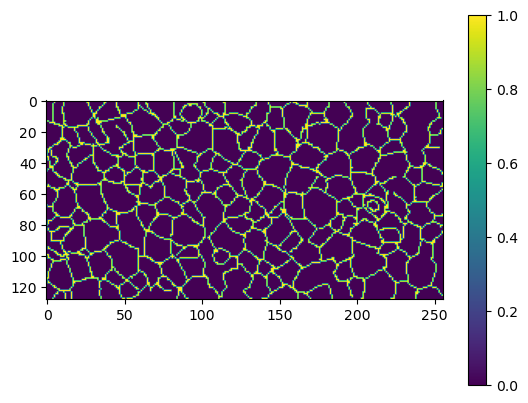

In [6]:
plt.imshow(a)
plt.colorbar()

In [14]:
print(a[1])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [19]:
b=np.where(a==0,1,0)

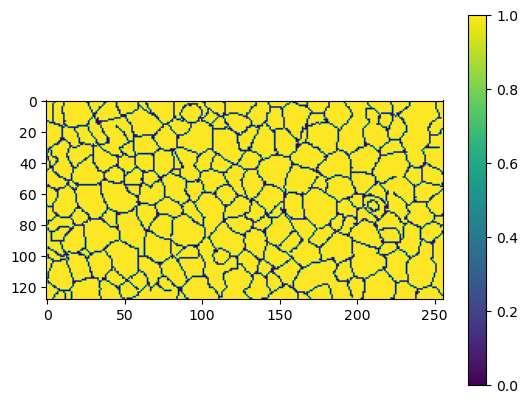

In [20]:
plt.imshow(b)
plt.colorbar()

In [7]:
#Single Gaussian Fitting function: 
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2*sigma**2))

In [8]:
mus = []
sigmas = []
scales = []
for i in range(a.shape[0]):
    x_data,voltage = np.histogram(a[i,:], bins='auto')
    #y_data = np.arange(x_data.shape[0])
    popt, pcov = curve_fit(gaussian, voltage[:-1],x_data, maxfev=100000000)
    scales.append(popt[0])
    mus.append(popt[1])
    sigmas.append(pcov[1,1])



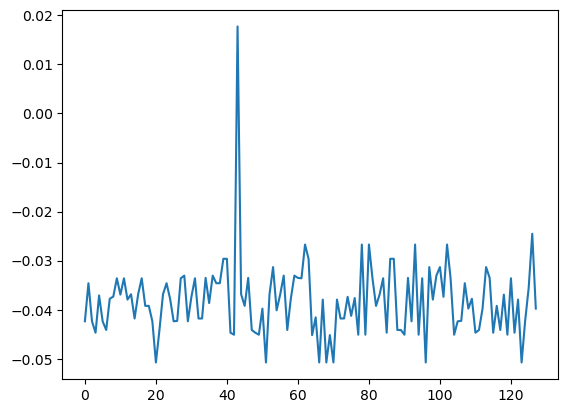

In [9]:
plt.plot(range(a.shape[0]),mus)

In [10]:
print(f"mu: {mus[-1]:.4},sigma: {sigmas[-1]:.4}")
#bin 14 mu: 0.2536,sigma: 5.85e-07
#bin 8 mu: 0.2529,sigma: 5.492e-07
#bin 20 mu: 0.2538,sigma: 8.041e-07
#bin 32 mu: 0.2541,sigma: 8.072e-07
#bin 4 mu: 0.2515,sigma: 1.795e-06
#bin 60 mu: 0.2543,sigma: 7.136e-07

mu: -0.03977,sigma: 4.398e+23


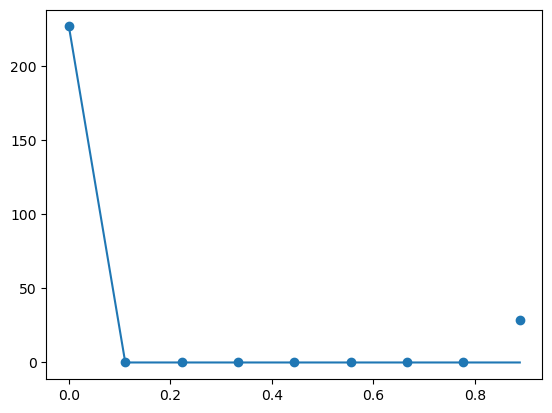

In [11]:
plt.scatter(voltage[:-1],x_data)
plt.plot(voltage[:-1], gaussian(voltage[:-1],*popt))

In [12]:
plt.scatter(x_data,y_data)
print(x_data.mean())
print(x_data.std())

#plt.plot(x_data, gaussian(x_data,*popt))

NameError: name 'y_data' is not defined

In [ ]:
b = np.loadtxt("testfile.txt",encoding='utf-8')
print(b[:,0]-voltage[:-1])

In [ ]:
b[:,1]

In [ ]:
x_data

In [ ]:
print(6*7.89217)